# Network Science (981G5) Assessment

Abstract\Introduction:
> Some text here

#### Contents
- [Notebook Setup](#notebook-setup)
- [1. Statbomb API: Raw Data Import](#1-statbomb-api-raw-data-import)
    - [1.1 Competition Extraction](#11-competition-extraction)
    - [1.2 Match, Team, Player and Events Extractions](#12-match-team-player-and-events-extractions)
    - [1.3 League Statistics](#13-league-statistics)
    - [1.4 Highest Match-Team Pass Total](#14-highest-match-team-pass-total)
- [2. Network](#2-network)
    - [2.1 Build Network Function](#21-build-network-function)
    - [2.2 Highest Pass Match Network](#22-highest-pass-match-network)
    - [2.3 Basic Network Visualisation](#23-basic-network-visualisation)
    - [2.4 Pitch Plotting Underlay](#24-pitch-plotting-underlay)
    - [2.5 Plotting Raw Passes](#25-plotting-raw-passes)
    - [2.6 Pitch Plot PassMap](#26-pitch-plot-passmap)
    - [2.7 Frameless Pitch Plot](#27-frameless-pitch-plot)
    - [2.8 Filtered PassMap](#28-filtered-passmap)
    - [2.9 Adjacency Matrix](#29-adjacency-matrix)
- [3. Degree Analysis](#3-degree-analysis)
    - [3.1 Micro-Level Player Metrics:](#31-micro-level-player-metrics)
    - [3.2 Macro-Level Network Heterogeneity](#32-macro-level-network-heterogeneity)
        - [Hub Identification](#hub-identification)
- [4. Average Shortest Path](#4-average-shortest-path)
    - [4.1 Global Average Shortest Path Length](#41-global-average-shortest-path-length)
    - [4.2 Player Average Level Path Length](#42-player-average-level-path-length)
    - [4.3 Visualizing Path Efficiency (Node Sizing)](#43-visualizing-path-efficiency-node-sizing)
    - [4.4 Inward vs. Outward Accessibility Scatterplot](#44-inward-vs-outward-accessibility-scatterplot)
- [5. Betweeness Centrality](#5-betweeness-centrality)
    - [5.1 Betweeness Table](#51-betweeness-table)
    - [5.2 Betweeness Node Network Plot](#52-betweeness-node-network-plot)
    - [5.3 Betweeness Bar Chart](#53-betweeness-bar-chart)
- [6. Transitive Triad Intensity (Local Clustering)](#6-transitive-triad-intensity-local-clustering)
    - [6.2 Global Clustering Metrics](#62-global-clustering-metrics)
        - [6.2.1 Mean Global Clustering](#621-mean-global-clustering)
        - [6.2.2 Normalized Global Clustering](#622-normalized-global-clustering)
    - [6.3 Player Level Clustering](#63-player-level-clustering)
    - [6.4 Top Active Transitive Triads](#64-top-active-transitive-triads)
    - [6.5 Overlaying Clustering Triads](#65-overlaying-clustering-triads)
- [7. Empirical Baselines](#7-empirical-baselines)
    - [7.1 Empirical Benchmarking](#71-empirical-benchmarking)
    - [7.2 Distribution of Pass Volumes](#72-distribution-of-pass-volumes)
        - [7.2.1 Histogram](#721-histogram)
        - [7.2.2 Table](#722-table)
        - [7.2.3 Formation Binning](#723-formation-binning)
- [8. Traditional Nulls](#8-traditional-nulls)
    - [8.1 Erdos Renyi (ER) Null Network](#81-erdos-renyi-er-null-network)
        - [8.1.1 Null PassMap Plot](#811-null-passmap-plot)
        - [8.1.2 Null Degree Analysis](#812-null-degree-analysis)
            - [8.1.2.1 Null Player-Level Degree Metrics](#8121-null-player-level-degree-metrics)
            - [8.1.2.2 Null Degree Macro-Level Metrics](#8122-null-degree-macro-level-metrics)
            - [8.1.2.3 Null Top Hubs](#8123-null-top-hubs)
        - [8.1.3 Null Clustering Analysis](#813-null-clustering-analysis)
            - [8.1.3.1 Global Clustering](#8131-global-clustering)
            - [8.1.3.2 Player-Level Clustering](#8132-player-level-clustering)
            - [8.1.3.3 Clustering Triads](#8133-clustering-triads)
            - [8.1.3.4 Clustering Polygon Plot](#8134-clustering-polygon-plot)
    - [8.2 Rewiring Null Approach](#82-rewiring-null-approach)
        - [8.2.1 Rewire vs Network Visual](#821-rewire-vs-network-visual)
        - [8.2.2 Verifying Structural Collapse](#822-verifying-structural-collapse)
- [9. Markovian Null Models](#9-markovian-null-models)



---

#### Notebook Setup

In [185]:
# ========================
# Installations
# ========================

# Install required dependencies
%pip install -q --upgrade pip
%pip install -q pandas statsbombpy networkx matplotlib jinja2 seaborn scipy

# Enable live auto-reloading for helpers.py updates
%load_ext autoreload
%autoreload 2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [186]:
# ========================
# Imports
# ========================

from typing import Optional, Tuple, Dict, List, Callable
import warnings
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from statsbombpy import sb
from statsbombpy.api_client import NoAuthWarning


# Custom helper module
import helper as hp

# Global notebook configurations
warnings.simplefilter("ignore", NoAuthWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Statbomb API: Raw Data Import
This the section that works on importing the raw events data from the Statsbomb and processing it in the form which is suitable for network analysis. Events data refers to identifable on-field actions, i.e. pass, tackle, shot. 

---

Section Contents: 
- [Heading 1]()
- [Heading 2]()

---

#### 1.1 Competition Extraction
StatBomb structure their data is various tables and granularly layers. We want to work with the 2023/2024 FA Women's Super League (`competition_id: 37`, `season_id: 281`) data. The code below queries to the `competitions` table to confirm that we have the correct codes. 

In [187]:
# Retrieve the competitions
competitions_df = sb.competitions()
print(f"Total Competitions Returned: {len(competitions_df)}")

# Filter the DataFrame for WSL 2023/2024
target_filter = (competitions_df['competition_id'] == 37) & (competitions_df['season_id'] == 281)
wsl_competition = competitions_df[target_filter].to_dict(orient='records')[0]

# Print the extracted row
print("\nExtracted Competition Payload:")
print(wsl_competition)

Total Competitions Returned: 80

Extracted Competition Payload:
{'competition_id': 37, 'season_id': 281, 'country_name': 'England', 'competition_name': "FA Women's Super League", 'competition_gender': 'female', 'competition_youth': False, 'competition_international': False, 'season_name': '2023/2024', 'match_updated': '2026-04-11T13:05:10.794831', 'match_updated_360': nan, 'match_available_360': nan, 'match_available': '2026-04-11T13:05:10.794831'}


In [174]:
COMPETITION_ID = 37
SEASON_ID = 281

### 1.2 Match, Team, Player and Events Extractions
To construct a Passing Network (PassMap), we need to extract and aggregate event-level data across individual matches. Each match yields two networks for the competing teams. In order to compile these team-match network we need to compile the nesecary information to structure our network and call the API for the specific information. 

1. **Nodes (Players):** Extracted from match lineups to determine player identity, tactical position, and appearance duration.
2. **Edges (Passes):** Extracted from match events to capture successfully completed passes between teammates.
3. **Graph Attributes:** Extracted to store tactical context, such as starting formations.

The following code offload processing to utilities held in `helper.py`.

| Function | Primary Purpose | Output/Pipeline Role |
| :--- | :--- | :--- |
| `hp.fetch_match_details()` | Downloads event stream and lineup payloads in a single API call. | Captures match duration (`max_minute`) and raw payloads. |
| `hp.extract_team_roster()` &<br>`hp.extract_11_players()` | Parses substitution timestamps and calculates individual appearances. | Computes total minutes played and isolates the core 11 players with highest volume. |
| `hp.extract_team_formation()` | Queries tactical setups (e.g., `4-3-3`, `3-4-3`) from starting XI events. | Attaches tactical system metadata to the team network. |
| `hp.extract_successful_passes()` | Filters out incomplete or intercepted passes. | Returns completed pass actions needed to build adjacency matrices. |

The result is a list of match-team entries containing: match id, team name, starting formation, team total passes, the full player roster including subs and the main team of 11 players who played the most minutes. This gives us all of the information be needed to query the API, pull the pass data and construct a network.

In [175]:
# Extract full seasons worth of match_ids
matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
matches = matches_df["match_id"].to_list()
print(f"WSL 23/24 contains {len(matches)} matches.")

match_records = []

for match in matches:
    events, lineups, max_minute = hp.fetch_match_details(match)
    for team_name, lineup_df in lineups.items():

        # Roster extraction 
        roster = hp.extract_team_roster(lineup_df, max_minute)
        top_11_players = hp.extract_11_players(roster)

        # Tactical and event extraction
        formation = hp.extract_team_formation(events, team_name)
        team_passes = hp.extract_successful_passes(events, team_name)
    
        match_records.append({
            "match_id": match,
            "team": team_name,
            "formation": formation,
            "total_passes": len(team_passes), # Absolute total, not 11
            "full_roster": roster,
            "top_11_players": top_11_players
        })

WSL 23/24 contains 132 matches.


In [164]:
print(f"{len(match_records)} team-match records extracted")
print(40*"=")
print("Sample[0]: ")
print("Match ID:", match_records[0]["match_id"])
print("Team Name:", match_records[0]["team"])
print("Formation:", match_records[0]["formation"])
print("Team Passes:", match_records[0]["total_passes"])
print("Full Roster", len(match_records[0]["full_roster"]))
print("Most Used Players:", len(match_records[0]["top_11_players"]))
print("Most Used Players:", match_records[0]["top_11_players"])
print("Top 3 Players in Roster:")
for p in match_records[0]["top_11_players"][:3]:
    print(
        f"  • {p['Player Name']} ({p['Position']}) - {p['Minutes Played']} mins"
    )


264 team-match records extracted
Sample[0]: 
Match ID: 3913082
Team Name: Brighton & Hove Albion WFC
Formation: 343
Team Passes: 204
Full Roster 16
Most Used Players: 11
Most Used Players: [{'Player Name': 'Maria Thorisdottir', 'Player ID': 4636, 'Position': 'Center Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Sophie Baggaley', 'Player ID': 16376, 'Position': 'Goalkeeper', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Emma Nanny Charlotte Kullberg', 'Player ID': 34500, 'Position': 'Left Wing Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Elisabeth Terland', 'Player ID': 276301, 'Position': 'Center Forward', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Guro Bergsvand', 'Player ID': 276304, 'Position': 'Right Center Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Jorelyn Andre

### 1.3 League Statistics
The code below uses the compile match records to pull some league level statistics. Of note we see that there are 105,262 accross the whole seasons, 264 networks (match-team) with an average of 399 passes which ranges from 120 to 847. This is important because passes accumulate to become the edges in our network.

In [ ]:
stats_dict = hp.calculate_league_summary_stats(match_records)

# ==============================================================================
# PRINT GENERATED TABLE STATS
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)")
print("=" * 60)
print(f"Total Matches Analyzed:                 {stats_dict['total_matches']}")
print(f"Total Team Match Networks:              {stats_dict['total_team_games']}")
print(f"Total Completed Season Passes:          {stats_dict['total_passes']:,}")
print(f"Mean Passes per Team per Match:         {stats_dict['mean_passes']:.1f} "
f"(Range: {stats_dict['min_passes']} - {stats_dict['max_passes']})")
print(f"Mean Unique Players Used per Game:      {stats_dict['mean_players_used']:.1f} "
f"(Range: {stats_dict['min_players_used']} - {stats_dict['max_players_used']})")
print("=" * 60)

### 1.4 Highest Match-Team Pass Total
The network we will focus on for this project is the match with the highest total of passes recorded by a single team. This match is of note because it is likely to have very few games, if any, which have a similar number of passes. We know that the number of passes impact the network topology and properties of PassMap, therefore, to formally analyse this network we need other networks with similar passes, otherwise the number of passes will dominate the topology. Therefore, this network is a new candidate and demonstrates why we will need null models for analysis.

In [ ]:
# Returns a tuple: (list_index, max_record_dict)
max_idx, highest_pass_match = max(
    enumerate(match_records), 
    key=lambda item: item[1]["total_passes"]
)

print(f"Record Index: {max_idx}")
print(f"Match ID:     {highest_pass_match['match_id']}")
print(f"Team:         {highest_pass_match['team']}")
print(f"Passes:       {highest_pass_match['total_passes']}")

## 2. Network
The Network section outlines the underlying infrastructure and connectivity framework, as well as, visualisation tooling.

---

Section Contents: 
- [Heading 1]()
- [Heading 2]()

---

#### 2.1 Build Network Function
To transform raw relational event data into formal graph representations, we construct a dedicated pipeline function, `build_passmap_network()`. This pipeline processes individual raw event instances from scratch to dynamically construct an attribute-enriched, directed, and weighted graph ($G \in \mathbb{R}^{V \times E}$)
- `extract_top11_pass_events()`: Filters the raw event log down to completed passes belonging strictly to the target team and the 11 modeled players.
- `compute_player_average_positions()`: Calculates each player's mean pitch coordinates $(\bar{x}, \bar{y})$ from their pass events, binding them to nodes as spatial attributes.
- `aggregate_pass_edges()`: Aggregates pairwise pass counts to assign directed edge weights (e.g., 30 completed passes from Player A to Player B yields an edge weight of 30).

The output is a weighted, direct network with node attributes. 

In [ ]:
def build_passmap_network(match_record: dict, events_df: Optional[pd.DataFrame] = None) -> nx.DiGraph:
    """Constructs a weighted, directed NetworkX graph (nx.DiGraph) for a team passmap.
    
    Parameters
    ----------
    match_record : dict
        A team-match dictionary containing 'match_id', 'team', and 'top_11_players'.
    events_df : pd.DataFrame, optional
        Pre-loaded events DataFrame for the match. If None, fetches directly via API.
            
    Returns
    -------
    nx.DiGraph
        Directed passmap graph.
    """
    # Compile the Match-Team records
    m_id = match_record["match_id"]
    team_name = match_record["team"]
    top_11_players = match_record["top_11_players"]
    top_11_ids = {p['Player ID'] for p in top_11_players}
    player_id_to_name = {p['Player ID']: p['Player Name'] for p in top_11_players}
    
    # API Fallback
    if events_df is None:
        events_df = sb.events(match_id=m_id)

    # Extract raw pass (Edges) and Position (Node) information
    passes_df = hp.extract_top11_pass_events(events_df, team_name, top_11_ids)
    avg_locations = hp.compute_player_average_positions(passes_df)
    
    G = nx.DiGraph(
    team_name=team_name,
    total_passes=match_record["total_passes"]
    )

    # Construct the network nodes from the 11 players
    for p in top_11_players:
        p_id, p_name, p_pos = p['Player ID'], p['Player Name'], p['Position']
        loc = avg_locations.get(p_id, {'x': 50.0, 'y': 50.0})
        
        G.add_node(
            p_name,
            player_id=p_id,
            position=p_pos,
            pos=(loc['x'], loc['y']),
            x=loc['x'],
            y=loc['y']
        )
        
    edges = hp.aggregate_pass_edges(passes_df, player_id_to_name)
    for passer, recipient, weight in edges:
        G.add_edge(passer, recipient, weight=weight)

    G.graph["true_total_passes"] = sum(d.get('weight', 0) for _, _, d in G.edges(data=True))
        
    return G

#### 2.2 Highest Pass Match Network
`G_highest` holds the PassMap network for the highest pass match

In [ ]:
# Pass the dictionary record directly
target_record = match_records[max_idx]
G_highest = build_passmap_network(target_record)

#### 2.3 Basic Network Visualisation
Here is an extremely basic visualisation of the network. While the format for the visualisation doesn't matter for most network properties, given we are analysing a spatially constrained game it is useful to see the network well formatted. In this implementation, the nodes are plotted as per their average pass position during the game. This basic implementation doesn't plot the edge weight

In [ ]:
# plt.figure(figsize=(4, 3))

# # Extract Node Locations
# pos = nx.get_node_attributes(G_highest, 'pos')

# # Draw basic graph
# nx.draw(G_highest, pos=pos)

# plt.title("Basic PassMap Network Topology")
# plt.axis("on")
# plt.grid(True)
# plt.show()

#### 2.4 Pitch Plotting Underlay
We introduce a custom pitch-underlay function (`draw_vertical_pitch()`) to visualize network nodes over a 2D spatial grid. While purely cosmetic with no effect on underlying graph metrics, rendering nodes at their mean pitch coordinates significantly improves readability and visual appeal. This helper was built natively with Matplotlib to avoid bloated third-party dependencies such as `mlpsoccer`.

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))

# Draw Pitch Underlay
hp.draw_vertical_pitch(ax=ax)

#### 2.5 Plotting Raw Passes
Here I am plotting the raw passes for a match-team and then an individual player within the match. This is demonstate just how messy and unintuative pass data is and why network analysis is so valuable.

In [ ]:

# Create a figure with 1 row and 2 columns
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RAW_TEAM = 'Arsenal WFC'
# RAW_NAME = 'Emily Ann Fox'
# RAW_MATCH = sb.events(match_id=3913160)

# # Plot the individual player passes on the first subplot
# hp.plot_player_raw_passes(RAW_MATCH, RAW_TEAM, RAW_NAME, ax=axes[0])
# axes[0].set_title('Emily Ann Fox')

# # Plot all team passes on the second subplot
# hp.plot_player_raw_passes(RAW_MATCH, RAW_TEAM, None, ax=axes[1])
# axes[1].set_title('Arsenal WFC (All Passes)')

# plt.tight_layout()
# plt.show()

#### 2.6 Pitch Plot PassMap
This section plots the network overlayed on the pitch. Typically, this is the most intuitive way to plot PassMaps as it gives us insight as to specific areas of the pitch that players operate in and provides us insight as to why certain relationships, clusters and pass routes may be forming. However, this network is very dense with pass volume and as a result makes it difficult to observe the edges. 

In [ ]:
# 1. Unpack fig and ax explicitly
# fig, ax = plt.subplots(figsize=(6.5, 9.0), facecolor='#ffffff')

# # 2. Call the passmap function with the explicitly assigned ax
# hp.plot_passmap_on_pitch(G_highest, ax=ax)

# plt.show()

#### 2.7 Frameless Pitch Plot
This visual retains the spatial coordinates but maximise the space in the images framing. 

In [ ]:
# Declare the figure window
# fig, ax = plt.subplots(figsize=(6.5, 9.0), facecolor='#ffffff')

# # Plot frameless graph
# hp.plot_passmap_frameless(G_highest, ax=ax)

# # Remove all external margins
# plt.tight_layout(pad=0.5)
# plt.show()

#### 2.8 Filtered PassMap
As the PassMap represents cumulative passes across an entire match it can be good to set a threshold from which edges are plotted by. This is partly done to improve the view of the network by "removing" edges. But functionally, this removes edges which don't represent any sort of relationship. Two players on the opposite sides of the pitch may make a single interaction in a defensive situation whereby their true positional roles have been compromised. Doing this intensifies stronger links. Note, this is generally just a cosmetic action, we don't tend to actually want to remove edges from the network itself.

In [ ]:
# Filter graph to only show pass combinations made at least 8 times
# G_threshold_8 = hp.filter_graph_edges(G_highest, min_weight=5)

# # Declare the figure window
# fig, ax = plt.subplots(figsize=(6.5, 9.0), facecolor='#ffffff')
# # hp.plot_passmap_on_pitch(G=G_threshold_8, ax=ax)
# hp.plot_passmap_frameless(G_threshold_8, ax=ax)
# plt.tight_layout(pad=0.5)
# plt.show()

#### 2.9 Adjacency Matrix

In [ ]:
import networkx as nx
import pandas as pd

# Convert to a labeled Pandas DataFrame
adj_df = nx.to_pandas_adjacency(G_highest, weight='weight', dtype=int)

print(adj_df)

adj_matrix = nx.to_numpy_array(G_highest, weight='weight')

print(adj_matrix)

## 3. Degree Analysis
To evaluate the structural balance and individual workloads within the passing network, we implement the `analyze_degree_and_heterogeneity()` pipeline. This function extracts both micro-level (player) and macro-level (team) **degree** network properties from the directed pass graph ($G$).

In [ ]:
# Analyze graph using the integrated function
player_df, macro_stats, top_hubs_df = hp.analyze_degree_and_heterogeneity(G_highest, top_n_hubs=5)

### 3.1 Micro-Level Player Metrics:
- Calculates unweighted in/out-degree ($k_{in}, k_{out}$) to measure the diversity of passing partners
- weighted in/out-strength ($s_{in}, s_{out}$) to quantify total passes received and completed.
- Net Flow ($\Delta s_i = s_{out} - s_{in}$) measures directional asymmetry to identify net distributors ($\Delta s_i > 0$) versus net receivers ($\Delta s_i < 0$).
- Pass Ratio ($s_{out} / s_{in}$) to idetnify positional roles, distinguish build-up playmakers ($> 1.0$) from target finishing endpoints 

In [ ]:
# 1. Player-Level Table
print("\n" + "="*90)
print("####Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df.to_string())

### 3.2 Macro-Level Network Heterogeneity
At the team level, we evaluate workload dispersion and network centralization:

| Metric | Notation | Formula / Code Variable | What It Measures |
| :--- | :--- | :--- | :--- |
| **Mean Unweighted Degree** | $\langle k \rangle$ | `mean_k` | Measures the average number of unique passing connections per player across the team. |
| **Degree Variance** | $\text{Var}(k)$ | `var_k` | Captures the spread of unique passing connections around the team mean. |
| **Degree Standard Deviation** | $\sigma_k$ | `std_k` | Quantifies the average dispersion of player connection counts from the squad average. |
| **Second Moment** | $\langle k^2 \rangle$ | `second_moment` | Measures the second moment of the unweighted degree distribution to emphasize the presence of highly connected hubs. |
| **Coefficient of Variation** | $CV_k$ | `cv_k` ($\sigma_k / \langle k \rangle$) | Measures unweighted degree heterogeneity to assess how unevenly unique passing channels are distributed across all players. |


In [ ]:
# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats.items():
    print(f"{metric_name:<45}: {val:.4f}")

### Hub Identification 
Ranks the top $N$ players by total pass volume ($s_{tot}$) and calculates their **Relative Volume** ($s_i / \langle s_{tot} \rangle$) to highlight the team's primary playmakers relative to the squad average.

In [ ]:
# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df.to_string(index=False))

## 4. Average Shortest Path
To evaluate how efficiently the ball circulates across the team, we calculate the all-pairs shortest path length using Dijkstra's algorithm. Because passing networks represent volume rather than physical distance, edge weights are inverted ($l_{ij} = 1 / w_{ij}$) so that high-frequency passing channels translate into short communication distances.

In [ ]:
d_global_arsenal, dist_matrix_df, player_path_df = hp.calculate_average_shortest_path(G_highest)

#### 4.1 Global Average Shortest Path Length
The global average shortest path length ($d$) measures the overall structural efficiency and compactness of the team's passing network.

In [ ]:
print("\n" + "="*80)
print(f"Part 1: Global Team Circulation Distance (d) - Arsenal WFC")
print("="*80)
print(f"Global Average Shortest Path Length (d): {d_global_arsenal:.4f} topological units")

#### 4.2 Player Average Level Path Length
To understand individual roles within the passing network, we disaggregate path lengths into inward accessibility ($d_{in}$) and outward reachability ($d_{out}$):

**Mean Outward Path Length ($d_{out}$):** Measures how efficiently a player can start a sequence and reach all other teammates through the passing network. Low $d_{out}$ values identify central build-up distributors who anchor possession. 

**Mean Inward Path Length ($d_{in}$):** Measures how easily all other teammates can route the ball into a specific player. This is critical for players positioned higher up the pitch or specialized targets who require longer or more deliberate sequences to access.

In [ ]:
print("\n" + "="*80)
print("Player-Level Path Length Summary (Ranked by Outward Efficiency)")
print("="*80)
print(player_path_df.to_string())

#### 4.3 Visualizing Path Efficiency (Node Sizing)
We can embed these shortest path metrics directly into the spatial PassMap visualization. The `plot_passmap_on_pitch()` function accepts a node_scores argument, allowing us to dynamically scale player node sizes based on path efficiency (where lower path lengths indicate higher efficiency and are mapped to larger node sizes).

In [ ]:
# Extract outward path lengths (d_out) into a dictionary
d_out_dict = player_path_df["Mean Outward Path Length (d_out)"].to_dict()

# Invert scores for node sizing (Smaller d_out = More efficient = LARGER node)
max_path = max(d_out_dict.values()) if d_out_dict else 1.0
path_efficiency_scores = {player: (max_path - score) for player, score in d_out_dict.items()}

# Plot passmap using your updated plot_passmap_on_pitch function
hp.plot_passmap_on_pitch(
    G=G_highest,
    node_scores=path_efficiency_scores,
    metric_name="Mean Shortest Path (d_global)",
    global_metric=f"{d_global_arsenal:.3f}"
)

#### 4.4 Inward vs. Outward Accessibility Scatterplot
Beyond spatial pitch visualisations, we can evaluate player roles by plotting a scatter distribution comparing each player's **Mean Inward Path Length ($d_{in}$)** against their **Mean Outward Path Length ($d_{out}$)**.

**Central Connectors & Build-up Hubs:** Players like Lotte Wubben-Moy and Kim Little cluster tightly at the lower end of both inward and outward paths, showing they are easily found by teammates and efficiently distribute the ball outward

**Peripheral Outlets & Outliers:** Stina Blackstenius (Center Forward) stands out as a clear outlier with significantly higher path lengths ($d_{out} \approx 0.566$, $d_{in} \approx 0.339$). She operates as the terminal forward meaning opposing defensive structures intentionally restrict passing lanes into her, resulting in higher topological distances from the rest of the build-up network. Similarly, attacking midfielders like Bethany Mead exhibit higher path lengths due to their advanced pitch positions, where casual possession loops are harder to establish.  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# EXECUTION
# ==============================================================================
hp.plot_path_length_scatterplot(
    player_path_df=player_path_df,
    d_global=d_global_arsenal,
    team_name=G_highest.graph.get('team_name', 'Team')
)

## 5.Betweeness Centrality
To move beyond simple passing volume and identify which players act as essential routing bridges within the team's tactical architecture, we evaluate **Betweenness Centrality ($g(i)$)**. 

In a passing network, high volume alone does not guarantee a player is a critical bridge; some players may exchange many passes with just a small group of teammates (e.g., full-backs and wingers). Betweenness centrality measures the proportion of all shortest paths passing through a given player, highlighting who controls the flow of possession between disparate zones of the team (such as connecting the defensive line to the midfield engine room).

The helper function below computes weighted shortest-path betweenness centrality for our directed passing network. NetworkX evaluates all-pairs shortest paths over these distances and computes the fraction of times each player sits directly on the shortest communication route between any other two teammates. Just like our shortest path analysis, the function converts raw pass counts into distance metrics ($1.0 / \text{weight}$), ensuring higher pass volumes represent shorter communication paths.

In [ ]:
betweenness_df, betweenness_dict = hp.calculate_betweenness_centrality(G_highest)

#### 5.1 Betweeness Table
The most simple way to analyse betweenness is to just plot a sorted table. Larger values are more central and important to the bridging of pass routes. High scoring players are "hubs" so facilitate the transition from one player to another. Low scores find themselves in the middle of less chains. It is common to see players with 0 scores. These tend to be wide periphery players or high/low players. Topologically, these players are the end or start destination rather than a routing option. However, with these players, low non-zeros scores are still interesting when compared to other traditionally low scoring players.

Interestingly, the CBs are the highest scoring players. At first this may not be intuitive because they are so deep on the pitch. However, it is not that we are the central linking players but they represent a constantly available passing option. From these "backpasses" a chain of possession is able to be established which in a dominant team may end up anyway on the pitch. It is this link, possession circulation and start point that is represented in their centralities.

In [ ]:
print("\n" + "="*80)
print("Part 2: Betweenness Centrality Analysis - Arsenal WFC")
print("="*80)
print(betweenness_df.to_string())

#### 5.2 Betweeness Node Network Plot
Given Betweenness is a player metric, it represents another property that we can visualise by varying the size of the players nodes. This property is much clearer to see on the network as there is a clear differential between the hub and non-hub players. See can see that the CB and CDMs behave as linkage players that facilitate the circulation and retention of possession. Additionally, we can pick that there is an asymmetry to the structure with the left-back behaving as  hub but the right back not. Finally, all of the attacking players are represented with small nodes.

In [ ]:
# Plot passmap with nodes sized by betweenness centrality
hp.plot_passmap_on_pitch(
    G=G_highest,
    node_scores=betweenness_dict,
    metric_name="Betweeness Centrality",
)

#### 5.3 Betweeness Bar Chart
Here is another example of how network properties can be visualised abstract from networks themselves. It is much easier for us to compare and see the difference between the higher scoring nodes this way. 

In [ ]:
# 1. Reset index and extract data
bet_plot = betweenness_df.reset_index()
bet_players = bet_plot["Player"]
bet_scores = bet_plot["Betweenness Centrality g(i)"]

# 2. Plot horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(bet_players, bet_scores, color="crimson", edgecolor="black")

# 3. Format chart (invert y-axis so highest score is at the top)
plt.gca().invert_yaxis()
plt.xlabel("Betweenness Centrality Score $g(i)$", fontweight="bold")
plt.title("Betweenness Centrality Ranking — Arsenal WFC", fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Transitive Triad Intensity (Local Clustering)
While degree and betweenness centralities capture individual reach and routing control, they treat connections in isolation. To measure local clustering and cohesive group dynamics within a passing network, we evaluate Pure Transitive Triad Intensity ($I_{transitive}$).

In football passing networks, standard unweighted clustering coefficients can be misleading because they treat all connections equally. Transitive triads specifically isolate progressive wall-passes and multi-option triangle combinations where Player A passes to Player B, Player B passes to Player C, and Player A also connects directly to Player C ($A \to B$, $B \to C$, $A \to C$). Essentially, this maps relationships focused on advancing or transitioning the ball from A to C with the support of B.

Because our network is weighted by pass volume, we weight each triad by its weakest link ($W_{min} = \min(W_{AB}, W_{BC}, W_{AC})$). If the $A \to C$ connection is strong but $A \to B$ is weak, it does not constitute a true functional cluster; the direct relationship between A and C simply exists independently.

Note that we deliberately avoid measuring complete, closed-loop triangles ($A \to B \to C \to A$), as cyclic passing rarely indicates tactical progression in football. A transitive sequence represents purposeful ball movement toward a target zone or player, even if that movement temporarily resets backward.

In [ ]:
global_internal_clust, global_norm_clust, player_clust, triad_clust = \
    hp.calculate_transitive_triad_intensity(G_highest)

#### 6.2 Global Clustering Metrics
In our implementation, each player accumulates a score based on the strength and volume of the transitive triads in which they participate. Players involved in numerous high-volume triads earn higher individual scores. From these individual values, we compute two global clustering metrics:

##### 6.2.1 Mean Global Clustering
This metric calculates the simple mean of all individual player clustering scores across the team:

$$\bar{I}_{transitive} = \frac{1}{N} \sum_{i=1}^{N} I_{transitive}(i)$$

It serves as an internal benchmark to evaluate relative player contribution. Players scoring above the mean act as key linkage hubs who sustain local combinations. However, this metric is less suitable for cross-team comparisons because teams with higher total pass volumes naturally generate higher raw triad scores. Consequently, it cannot distinguish whether a team is inherently more tactically cohesive or simply completing more total passes.

A high(er) value of 582.55 might indicidate the strong presence of short-passing combinations and positional triangles rather than direct, long passes or individual dribbling. Though we can't say for sure. 


In [ ]:
print("\n" + "="*80)
print(f"Global Team Transitive Triad Clustering (Mean): {global_internal_clust:.4f} pass units")
print("\n" + "="*80)

##### 6.2.2 Normalized Global Clustering
To enable valid cross-team analysis, this approach normalizes the mean clustering score against the team's internal range of scores (or total pass volume):
$$I_{norm} = \frac{\bar{I}_{transitive} - I_{min}}{I_{max} - I_{min}}$$
This informs us how evenly triad participation is distributed across the entire squad rather than relying on a few isolated key players. Comparing this normalized score across different teams reveals true structural cohesion, allowing us to identify whether a team's build-up play relies on team-wide fluid combinations or isolated, localized interactions.

A normalized score of 0.5006 (~50.1%) means that out of all possible theoretical passing triads that could have been completed within the team's overall passing structure, roughly half of them were fully realized.

Our clustering approach doesn't normalaize against the max theoretical clustering figure but instead against the max players clustering and therefore the teams range. This allows us to normalize against teams passing volumnes and compare accross teams.


In [ ]:
print("\n" + "="*80)
print(f"Global Team Transitive Triad Clustering (Norm): {global_norm_clust:.4f}")
print("\n" + "="*80)

#### 6.3 Player Level Clustering
This highlights the Double-Pivot Engine of Kim Little ($1.000$) and Victoria Pelova ($0.854$) who dominate in the triad metrics. Many triangular passing combinations flow through the central double-pivot meaning they act as the primary link between the defense and attack. 

The central defensive players Wubben-Moy ($0.790$) and Leah Williamson ($0.738$) also record high triad values showing that Arsenal heavily utilizes short, triangular combinations out of the back to bypass opponent pressing lines rather than long, direct clearances

Steph Catley ($0.565$) records noticeably higher triad involvement than Emily Fox ($0.430$). Combined with Wubben-Moy's edge over Williamson, this indicates a strong tactical preference for building up along the left channel.

Alessia Russo shows as a Hybrid Link operating in a deeper central attacking role here, Alessia Russo ($0.561$) posts strong triad involvement, showing she frequently drops deep to connect with Little and Pelova. Note, that she does not show up in Shortest Path. This may be due to her linking up with general possession, i.e. not the shortest, or should this metrics abiltiy to capture all players in a cluster, with her being often the target player C.

Also, note that Stina Blackstenius is still 0 for this. She doesn't follow Russo's inclusion parameters, she is simply the final point always and not involved in possession.

In [ ]:
print("\n" + "="*80)
print("Player-Level Transitive Triad Summary")
print("="*80)
print(player_clust.to_string())

#### 6.4 Top Active Transitive Triads
By extracting the active triads ranked by bottleneck capacity, we can isolate the exact tactical triangles where the team successfully executed passing loops.

In [ ]:
print("\n" + "="*80)
print("Top 10 Active Transitive Triads")
print("="*80)
top_triads_summary = []
for idx, t in enumerate(triad_clust[:10], start=1):
    p1, p2, p3 = t["players"]
    top_triads_summary.append({
        "Rank": idx,
        "Player 1 (Origin/Target)": p1,
        "Player 2 (Intermediate)": p2,
        "Player 3 (Target/Origin)": p3,
        "Total Capacity (Pass Units)": round(t["total_capacity"], 2)
    })

top_triads_df = pd.DataFrame(top_triads_summary).set_index("Rank")
print(top_triads_df.to_string())

#### 6.5 Overlaying Clustering Triads
A good way to visualise the key triads is by overlaying the triad clusters on the PassMap. This can help to provide structure to the otherwise chaotic PassMap, allowing us to transform edge density into coordinate passing clusters

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 9.0), facecolor='#ffffff')

hp.draw_vertical_pitch(ax=ax)
hp.plot_passmap_on_pitch(G_highest,ax=ax)
hp.plot_transitive_triads_updated(G=G_highest, triads=triad_clust, top_n=4, ax=ax)

title=G_highest.graph.get('team_name', 'Team')
ax.set_title(f"Top Transitive Triads (Passing Triangles)\n{title}", )
plt.tight_layout()
plt.show()

## 7. Empirical Baselines
Now that we have a network and properties, we want compare them to something. Some network properties allow us to infer information about the network abstract from any baseline, i.e. if something has hetrogenity. However, for the purpose of football, most of our analysis will need tobe benchmarked or reference. For anything, the obvious starting point for comparisons is other literal networks, empirical comparisons.

`compute_league_global_shortest_paths()` worss through the `match_records` and compiles a network for each match-team instance and then computes its global shortest path. Resulting, we have a range of metric values to try and benchmark our network against

In [ ]:
league_sp = hp.compute_league_global_shortest_paths(match_records)
league_sp.sort_values(by="d_global", ascending=True, inplace=True)
league_sp

#### 7.1 Empirical Benchmarking
Empirical benchmarking clearly ranks our network ($0.1884$) as one of the most efficent networks in the league. It ranks at the top 10 network, $3.41$% and very close to the league minimum of $0.1748$. 

In [ ]:
rank, percentile, series_stats = hp.evaluate_global_d(G_highest, league_sp)

#### 7.2 Distribution of Pass Volumes
Given we selected the match with the highest overall pass volume, our network represents a top-percentile (>99th percentile) outlier. Even when grouping matches into broad 100-pass bins, the volume distribution remains extremely sparse at higher ranges.

The 700–799 pass range contains only our selected match. Neighboring ranges are similarly sparse: 600–699 passes contains 8 matches, 500–599 contains 14, and 100–199 contains 22. Even the most populated range (200–299 passes) accounts for only 94 of the 234 total matches ($40.2\%$).

This sparsity poses a critical methodological challenge. Network properties are strongly shaped by node degrees (pass counts); reliable empirical benchmarking requires comparing matches with similar pass volumes. Finding comparable matches is impossible for our selected game and difficult for most matches in the dataset.

Adding tactical variables further exacerbates this issue. To ensure fair comparisons, matches must also be split by tactical formation, which dictates baseline network topology. As Section 7.2.3 shows, segmenting the largest pass-volume bin (94 matches) across 11 formations leaves the most common setup (4-2-3-1) with only 29 matches ($30.9\%$).

Finally, empirical baselines require an even distribution of distinct teams within each bucket. Otherwise, benchmarks risk comparing teams primarily against themselves.

Together, these factors highlight the severe data-sparsity constraints inherent to constructing empirical baselines.


##### 7.2.1 Histogram

In [ ]:
hp.plot_league_pass_distribution(league=league_sp, G=G_highest)

##### 7.2.2 Table

In [ ]:
bin_edges = list(range(0, 1001, 100))

bin_counts = pd.cut(league_sp["Total_Passes"], bins=bin_edges, right=False
    ).value_counts(sort=False)

bin_table = pd.DataFrame({
        "Pass Range": [f"{int(b.left)}–{int(b.right) - 1}" for b in bin_counts.index],
        "Match Count (n)": bin_counts.values,
        "Percentage (%)": (bin_counts.values / len(league_sp) * 100).round(2),
    })

bin_table

##### 7.2.3 Formation Binning

In [ ]:
# Filter bin and get counts + percentages
bin_df = league_sp[league_sp["Total_Passes"].between(300, 399)]
formation_counts = bin_df["Formation"].value_counts()

formation_summary = pd.DataFrame({
    "Match Count (n)": formation_counts,
    "Percentage (%)": (formation_counts / len(bin_df) * 100).round(2)
}).reset_index(names="Starting Formation")

print(f"Total Matches: {len(bin_df)} | Unique Formations: {len(formation_summary)}")
print(formation_summary)

## 8. Traditional Nulls
The issues with filtering data sparsity clearly demonstrate the limitations of empirical benchmarking and highlight the need for null/random baselines. However, traditional null approaches face significant hurdles when applied to association football. Generating a network null model involves randomizing certain topological features while preserving selected properties, such as node degree. The core issue is that football is inherently spatially constrained by physics and the dimensions of the pitch. Furthermore, tactical and behavioral nuances dictate network topology; a typical match consists of short, progressive passes aimed at advancing the ball into high-value zones near the opposition goal, which are then decomposed into pass-map networks. Traditional null models fail to account for these domain-specific constraints, often yielding nonsensical graph structures—such as unnatural cross-field connections or high-degree hubs in impossible positions (e.g., the goalkeeper).

### 8.1 Erdos Renyi (ER) Null Network
The simplest approach to constructing a network null model is the Erdős–Rényi (ER) random graph model. 

Under the $G(N, p)$ formulation, an ER network is generated by taking $N$ nodes and drawing an edge between every pair of nodes independently with a uniform probability $p$. In the context of weighted networks, this approach preserves the total weight (e.g., total passes) across the network, but completely destroys the underlying topological structure. The network is rebuilt by distributing edge weights incrementally, one unit at a time, based on a probability distribution derived from the total network weight and node count. Because edge placement is entirely random, all nodes are treated as structural equals, resulting in a homogeneous degree distribution where individual node degree constraints are discarded.

In [ ]:
# Null Construction
G_null_er = hp.generate_erdos_renyi_null_incremental(G_highest, seed=432)

# Verify invariants
print(f"Nodes Preserved: {len(G_null_er.nodes())}")
print(f"Note Attributes: {G_null_er.nodes[list(G_null_er.nodes())[0]]}")
print(f"Total Passes:    {sum(d['weight'] for _, _, d in G_null_er.edges(data=True))}")

# Compute betweenness scores for Null
betweenness_df_ER, betweenness_dict_ER = hp.calculate_betweenness_centrality(G_null_er)


#### 8.1.1 Null PassMap Plot
Plotting the expected goals (ER) PassMap immediately reveals structural anomalies. The network resembles a dense "hairball," with unilateral connections spanning the entire length of the pitch and no noticeable variance in edge widths.

Additionally, the striker unexpectedly appears as the central passing hub—an outcome that, while technically possible, is highly improbable to this degree. Similarly, the goalkeeper exhibits consistent, cross-field links with multiple outfield players.

When applying a 10-pass minimum filter, the original network dropped many connections, but this plot retains nearly all of them—including those involving the goalkeeper.

In [ ]:
# Filter graph to only show pass combinations made at least 8 times
G_null_thres = hp.filter_graph_edges(G_null_er, min_weight=10)

FIG_SIZE=(6.5, 9.0) # FIG_SIZE=(18, 27)
fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor='#ffffff')
hp.plot_passmap_frameless(
    G=G_null_thres, 
    ax=ax,
    node_scores=betweenness_dict_ER,
);

#### 8.1.2 Null Degree Analysis
The macro level degree analysis highlights that the ER null network no longer looks like a football network. There is very narrow degree variance ($\text{Var}(k) = 4.0661$, $\sigma_k = 2.0165$) with the tandard deviation is very small relative to the mean degree ($\langle k \rangle = 15.4545$). This means virtually every node in this baseline/null model has between 13 and 17 connections with little localised variation. Also the low Coefficient of Variation ($\text{CV}_k = 0.1305$ tells us the network is mathematicallya tightly clustered, Poisson-like or quasi-regular degree distribution. Futhermore,the Normalized Second Moment  is ($\langle k^2 \rangle / \langle k \rangle = 15.7176$). In scale-free or heterogeneous networks, this metric explodes due to heavy tails and hubs ($\langle k^2 \rangle \gg \langle k \rangle$). Here, $\frac{\langle k^2 \rangle}{\langle k \rangle} \approx \langle k \rangle + 0.26$, confirming the complete absence of extreme hub nodes.

In [ ]:
# Analyze graph using the integrated function
player_df_er, macro_stats_er, top_hubs_df_Er = hp.analyze_degree_and_heterogeneity(G_null_er, top_n_hubs=5)

##### 8.1.2.1 Null Player-Level Degree Metrics

In [ ]:
# 1. Player-Level Table
print("\n" + "="*90)
print("#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df_er.to_string())

##### 8.1.2.2 Null Degree Macro-Level Metrics

In [ ]:
# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats_er.items():
    print(f"{metric_name:<45}: {val:.4f}")

##### 8.1.2.3 Null Top Hubs

In [ ]:
# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df_Er.to_string(index=False))

#### 8.1.3 Null Clustering Analysis
An intuitive way to present the disfigurement of the null network is to compute the clustering triads. Clustering is a downstream metric that imputes several moving parts. To start, the global internal clustering metric rises to $708.54$. This tells us the connectivity of the network has become richer and more interconnected. There now exists a higher proportion of high quality clusters pulling up the network's average. This happens because the graph is now highly connected and homogenous, it's not that there are localized clusters but now the whole network is made up of dense clusters.

That biggest give away that the Null has failed comes through inspecting the triads. The 2nd strongest triad comprises an $A \to B \to C$ connection between Sabrina D’Angelo, Emma Stina Blackstenius and Emily Ann Fox. That is the goalkeeper to the striker to the rightback. This is a near impossible passing triangle, let alone the strongest triad. This is visualised in the polygon plot as an absurd overlayering of pitch wide, non-local clusters.

In [ ]:
global_internal_clust_er, global_norm_clust_er, player_clust_er, triad_clust_er = \
    hp.calculate_transitive_triad_intensity(G_null_er)

#### 8.1.3.1 Global Clustering

In [ ]:
print("\n" + "="*80)
print(f"Global Team Transitive Triad Clustering (Mean): {global_internal_clust_er:.4f} pass units")
print("\n" + "="*80)

#### 8.1.3.2 Player-Level Clustering

In [ ]:
print("\n" + "="*80)
print("Player-Level Transitive Triad Summary")
print("="*80)
print(player_clust_er.to_string())

#### 8.1.3.3 Clustering Triads

In [ ]:
print("\n" + "="*80)
print("Top 10 Active Transitive Triads")
print("="*80)
top_triads_summary = []
for idx, t in enumerate(triad_clust_er[:10], start=1):
    p1, p2, p3 = t["players"]
    top_triads_summary.append({
        "Rank": idx,
        "Player 1 (Origin/Target)": p1,
        "Player 2 (Intermediate)": p2,
        "Player 3 (Target/Origin)": p3,
        "Total Capacity (Pass Units)": round(t["total_capacity"], 2)
    })

top_triads_df = pd.DataFrame(top_triads_summary).set_index("Rank")
print(top_triads_df.to_string())


#### 8.1.3.4 Clustering Polygon Plot

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 9.0), facecolor='#ffffff')

hp.draw_vertical_pitch(ax=ax)
hp.plot_passmap_on_pitch(G_null_er,ax=ax)
hp.plot_transitive_triads_updated(G=G_null_er, triads=triad_clust_er, top_n=4, ax=ax)

title=G_null_er.graph.get('team_name', 'Team')
ax.set_title(f"Top Transitive Triads (Passing Triangles)\n{title}", )
plt.tight_layout()
plt.show()

### 8.2 Rewiring Null Approach
To address the limitations of the Erdős–Rényi model, we implement a degree-preserving randomization approach (a directed Configuration Model). This method rewires edge connections while strictly preserving each player's exact in-degree ($k_{\text{in}}$) and out-degree ($k_{\text{out}}$) sequences. By swapping destination endpoints between pairs of directed edges, this approach isolates whether observed tactical structures—such as spatial clustering or shortest path lengths—arise merely from individual player involvement rates or from deliberate, non-random passing combinations.

Despite its theoretical advantages, the rewiring approach ultimately fails due to topological saturation. In a network of this size ($N=11$) and high edge density, preserving directed degree sequences leaves almost no structural degrees of freedom for valid swaps. Out of $60,764$ swap attempts, only $890$ were successful—a swap success rate of just $1.46\%$. When a dense, degree-constrained graph runs out of eligible edge pairs to swap without introducing self-loops, multi-edges, or violating degree constraints, the algorithm collapses into generating a near-identical clone of the empirical network.

In [ ]:
G_null_rewired = hp.generate_whole_edge_rewired_null(G_highest, seed=42)

# Verify degree sequence preservation:
emp_in_deg = [d for n, d in G_highest.in_degree()]
null_in_deg = [d for n, d in G_null_rewired.in_degree()]
print(f"In-Degree Sequence Preserved: {emp_in_deg == null_in_deg}")

#### 8.2.1 Rewire vs Network Visual 

In [ ]:

# Adjust total width to fit two plots side-by-side (13.0 width = 6.5 * 2)
FIG_SIZE = (13.0, 9.0)
fig, ax = plt.subplots(1, 2, figsize=FIG_SIZE, facecolor="#ffffff")

# Left plot
hp.plot_passmap_frameless(
    G=G_null_rewired,
    ax=ax[0],
    # node_scores=betweenness_dict_ER,
)

# Right plot
hp.plot_passmap_frameless(
    G=G_highest,
    ax=ax[1],
    # node_scores=betweenness_dict_ER,
)

plt.tight_layout()
plt.show()

#### 8.2.2 Verifying Structural Collapse
To formally demonstrate this structural collapse, we evaluated the alignment between the empirical network ($G$) and the rewired baseline ($G_{\text{null}}$):

Adjacency Correlation: The Pearson correlation coefficient between the flattened empirical and rewired adjacency matrices reached $r = 0.7168$, proving that weight placements remained heavily locked in place.

Top-Edge Retention Rate: Across the top $25\%$ highest-weighted edges, retention rates ranged between $91.04\%$ and $100.00\%$ across multiple runs.

These diagnostics confirm that the primary passing channels could not rewire. The combination of high edge density and strict degree constraints deprives the network of the topological flexibility needed to construct a randomized baseline, rendering the degree-preserving configuration model ineffective for this match.

In [ ]:
r_val = hp.compute_adjacency_correlation(G_highest, G_null_rewired)
print(f"Adjacency Matrix Correlation (r):  {r_val:.4f}")


In [ ]:
retention_val_5 = hp.compute_top_k_edge_retention(G_highest, G_null_rewired, top_percent=0.05)
retention_val_10 = hp.compute_top_k_edge_retention(G_highest, G_null_rewired, top_percent=0.10)
retention_val_25 = hp.compute_top_k_edge_retention(G_highest, G_null_rewired, top_percent=0.25)
retention_val_50 = hp.compute_top_k_edge_retention(G_highest, G_null_rewired, top_percent=0.50)
retention_val_75 = hp.compute_top_k_edge_retention(G_highest, G_null_rewired, top_percent=0.75)

print(f"Top 25% Edge Retention Rate:        {retention_val_5 * 100:.2f}%")
print(f"Top 25% Edge Retention Rate:        {retention_val_10 * 100:.2f}%")
print(f"Top 25% Edge Retention Rate:        {retention_val_25 * 100:.2f}%")
print(f"Top 25% Edge Retention Rate:        {retention_val_50 * 100:.2f}%")
print(f"Top 25% Edge Retention Rate:        {retention_val_75 * 100:.2f}%")

## 9. Markovian Null Models

#### Pitch Grid

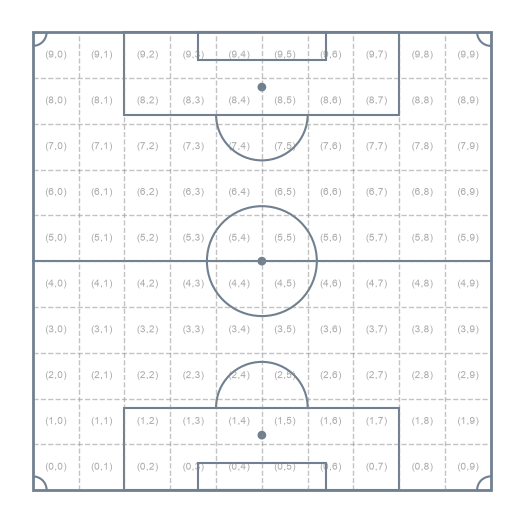

In [214]:
fig, ax = plt.subplots(figsize=(6.5, 9.0))
hp.draw_pitch_with_grid(
    original_pitch_func=hp.draw_vertical_pitch,
    ax=ax,
    grid_size=(10, 10),
    show_bin_labels=True
)
plt.show()

#### Construct League-Wide Pass Dataset

In [218]:
from statsbombpy import sb
from statsbombpy.api_client import NoAuthWarning

matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
matches = matches_df["match_id"].to_list()

pass_match_records = []

for idx, match in matches_df.iterrows():
    m_id = match['match_id']
    events_df = sb.events(match_id=m_id)
    passes = hp.extract_passes_with_recipient_position(events_df)
    pass_match_records.append(passes)

all_passes_df = pd.concat(pass_match_records, ignore_index=True)
print(f"\nTotal passes compiled across {len(matches_df)} matches: {len(all_passes_df):,}")


Total passes compiled across 132 matches: 105,262
